Data acquired from https://www.kaggle.com/datasets/jamiewelsh2/nba-per-game-player-statistics-2022-2023-season

In [1]:
import numpy as np
import pandas as pd

In [2]:
nba = pd.read_csv('nba_per_game_processed.csv')

In [3]:
nba.head()

,Index,Player Name,Position,Age,Team,GP,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Player-additional
0,1,Precious Achiuwa,C,23,TOR,55,12,20.7,3.6,7.3,...,1.8,4.1,6.0,0.9,0.6,0.5,1.1,1.9,9.2,achiupr01
1,2,Steven Adams,C,29,MEM,42,42,27.0,3.7,6.3,...,5.1,6.5,11.5,2.3,0.9,1.1,1.9,2.3,8.6,adamsst01
2,3,Bam Adebayo,C,25,MIA,75,75,34.6,8.0,14.9,...,2.5,6.7,9.2,3.2,1.2,0.8,2.5,2.8,20.4,adebaba01
3,4,Ochai Agbaji,SG,22,UTA,59,22,20.5,2.8,6.5,...,0.7,1.3,2.1,1.1,0.3,0.3,0.7,1.7,7.9,agbajoc01
4,5,Santi Aldama,PF,22,MEM,77,20,21.8,3.2,6.8,...,1.1,3.7,4.8,1.3,0.6,0.6,0.8,1.9,9.0,aldamsa01


In [4]:
len(nba)

539

In [5]:
nba.columns

Index(['Index', 'Player Name', 'Position', 'Age', 'Team', 'GP', 'GS', 'MP',
       'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%',
       'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV',
       'PF', 'PTS', 'Player-additional'],
      dtype='object')

In [6]:
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt

In [7]:
nba.isnull().sum()

Index                 0
Player Name           0
Position              0
Age                   0
Team                  0
GP                    0
GS                    0
MP                    0
FG                    0
FGA                   0
FG%                   2
3P                    0
3PA                   0
3P%                  16
2P                    0
2PA                   0
2P%                   5
eFG%                  2
FT                    0
FTA                   0
FT%                  24
ORB                   0
DRB                   0
TRB                   0
AST                   0
STL                   0
BLK                   0
TOV                   0
PF                    0
PTS                   0
Player-additional     0
dtype: int64

In [8]:
nba['Position'].value_counts()

SG       126
C        108
SF       103
PF       102
PG        91
SG-PG      2
SF-SG      2
PG-SG      2
SF-PF      1
PF-C       1
PF-SF      1
Name: Position, dtype: int64

In [9]:
nba.loc[nba['Position']=='SG-PG', 'Position']='SG'
nba.loc[nba['Position']=='SF-SG', 'Position']='SF'
nba.loc[nba['Position']=='PG-SG', 'Position']='PG'
nba.loc[nba['Position']=='SF-PF', 'Position']='SF'
nba.loc[nba['Position']=='PF-C', 'Position']='PF'
nba.loc[nba['Position']=='PF-SF', 'Position']='PF'

In [10]:
nba['Position'].value_counts()

SG    128
C     108
SF    106
PF    104
PG     93
Name: Position, dtype: int64

In [11]:
nba.loc[nba['PTS']==0]

,Index,Player Name,Position,Age,Team,GP,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Player-additional
66,67,Sterling Brown,SF,27,LAL,4,0,6.0,0.0,1.0,...,0.8,1.3,2.0,0.5,0.8,0.0,0.0,1.0,0.0,brownst02
72,73,Deonte Burton,PF,29,SAC,2,0,3.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,burtode02
150,151,Michael Foster Jr.,PF,20,PHI,1,0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,fostemi02
232,233,Frank Jackson,PG,24,UTA,1,0,5.0,0.0,3.0,...,1.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,jacksfr01
514,515,Alondes Williams,SG,23,BRK,1,0,5.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,2.0,1.0,0.0,willial06


<AxesSubplot:>

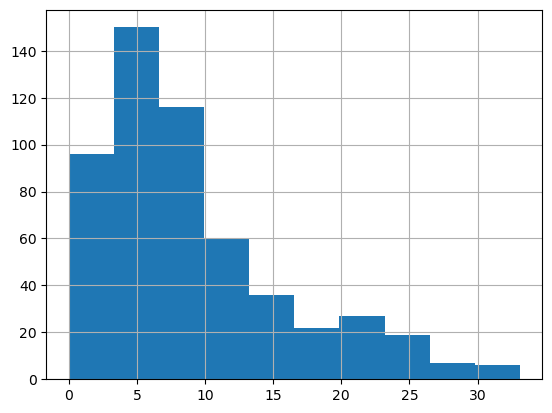

In [12]:
nba['PTS'].hist()

The code that follows up until the scatter matrix is dropping the lesser correlated features with the labels (PTS), and dropping other features to alleviate multicollinearity.

In [13]:
corr_matrix = nba.corr()
corr_matrix['PTS'].sort_values(ascending=False)

PTS      1.000000
FG       0.991753
FGA      0.982079
2PA      0.928116
2P       0.913772
FT       0.900180
FTA      0.890284
MP       0.874258
TOV      0.852160
GS       0.749886
AST      0.722104
3PA      0.715586
DRB      0.714267
3P       0.702705
TRB      0.635391
PF       0.603935
STL      0.581842
GP       0.506893
BLK      0.327158
ORB      0.304307
FT%      0.228789
eFG%     0.195366
FG%      0.187886
3P%      0.182470
2P%      0.119034
Age      0.101426
Index   -0.055093
Name: PTS, dtype: float64

In [14]:
nba = nba.drop(columns=['Index', 'Player Name', '2P%', 'Age', 'ORB', 'BLK', '3P%', 'FT%', 'FG%', 'eFG%', 'Team',
         'Player-additional'])

In [15]:
corr_matrix = nba.corr()
corr_matrix['FG'].sort_values(ascending=False)

FG     1.000000
PTS    0.991753
FGA    0.977333
2PA    0.949772
2P     0.943067
MP     0.879244
FT     0.862378
FTA    0.861896
TOV    0.850130
GS     0.758037
DRB    0.745471
AST    0.712958
TRB    0.676923
3PA    0.671131
3P     0.659124
PF     0.626487
STL    0.581773
GP     0.513014
Name: FG, dtype: float64

In [16]:
nba = nba.drop(columns=['FG'])

In [17]:
corr_matrix=nba.corr()
corr_matrix['PTS'].sort_values(ascending=False)

PTS    1.000000
FGA    0.982079
2PA    0.928116
2P     0.913772
FT     0.900180
FTA    0.890284
MP     0.874258
TOV    0.852160
GS     0.749886
AST    0.722104
3PA    0.715586
DRB    0.714267
3P     0.702705
TRB    0.635391
PF     0.603935
STL    0.581842
GP     0.506893
Name: PTS, dtype: float64

In [18]:
nba=nba.drop(columns=['FGA'])

In [19]:
corr_matrix=nba.corr()
corr_matrix['2PA'].sort_values(ascending=False)

2PA    1.000000
2P     0.984689
PTS    0.928116
FTA    0.884455
FT     0.870441
TOV    0.839994
MP     0.800698
DRB    0.740599
GS     0.712725
TRB    0.694750
AST    0.691245
PF     0.595087
STL    0.545882
3PA    0.455081
GP     0.454634
3P     0.425371
Name: 2PA, dtype: float64

In [20]:
nba=nba.drop(columns=['2P', '3P', 'FT'])

In [21]:
corr_matrix=nba.corr()
corr_matrix['PTS'].sort_values(ascending=False)

PTS    1.000000
2PA    0.928116
FTA    0.890284
MP     0.874258
TOV    0.852160
GS     0.749886
AST    0.722104
3PA    0.715586
DRB    0.714267
TRB    0.635391
PF     0.603935
STL    0.581842
GP     0.506893
Name: PTS, dtype: float64

In [22]:
corr_matrix

,GP,GS,MP,3PA,2PA,FTA,DRB,TRB,AST,STL,TOV,PF,PTS
GP,1.000000,0.641064,0.649675,0.406479,0.454634,0.392901,0.506849,0.486237,0.340165,0.414046,0.404578,0.514726,0.506893
GS,0.641064,1.000000,0.828853,0.529891,0.712725,0.635633,0.681401,0.643836,0.566952,0.563894,0.643229,0.610872,0.749886
MP,0.649675,0.828853,1.000000,0.696892,0.800698,0.708436,0.750114,0.688273,0.730342,0.721044,0.786539,0.752815,0.874258
3PA,0.406479,0.529891,0.696892,1.000000,0.455081,0.446908,0.328071,0.203078,0.554130,0.467127,0.560261,0.367351,0.715586
2PA,0.454634,0.712725,0.800698,0.455081,1.000000,0.884455,0.740599,0.694750,0.691245,0.545882,0.839994,0.595087,0.928116
FTA,0.392901,0.635633,0.708436,0.446908,0.884455,1.000000,0.669383,0.618635,0.628892,0.472728,0.789838,0.514184,0.890284
DRB,0.506849,0.681401,0.750114,0.328071,0.740599,0.669383,1.000000,0.972545,0.499652,0.459418,0.679979,0.709439,0.714267
TRB,0.486237,0.643836,0.688273,0.203078,0.694750,0.618635,0.972545,1.000000,0.406246,0.407816,0.605704,0.713781,0.635391
AST,0.340165,0.566952,0.730342,0.554130,0.691245,0.628892,0.499652,0.406246,1.000000,0.652689,0.831566,0.463605,0.722104
STL,0.414046,0.563894,0.721044,0.467127,0.545882,0.472728,0.459418,0.407816,0.652689,1.000000,0.567522,0.530042,0.581842


In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from statsmodels.tools.tools import add_constant
nba_vif = nba.drop(['PTS', 'Position'], axis = 1)
nba_vif = add_constant(nba_vif)
vif_df = pd.DataFrame()
vif_df['features'] = nba_vif.columns
vif_df['vif'] = [variance_inflation_factor(nba_vif.values, i)
                    for i in range(len(nba_vif.columns))]
vif_df

,features,vif
0,const,10.141814
1,GP,2.006039
2,GS,3.635697
3,MP,15.659654
4,3PA,3.594685
5,2PA,8.182259
6,FTA,4.920780
7,DRB,30.973482
8,TRB,31.267778
9,AST,4.837724


In [24]:
nba = nba.drop(columns=['GS', 'FTA', 'MP', 'TOV', 'TRB'])

In [25]:
corr_matrix = nba.corr()
corr_matrix

,GP,3PA,2PA,DRB,AST,STL,PF,PTS
GP,1.000000,0.406479,0.454634,0.506849,0.340165,0.414046,0.514726,0.506893
3PA,0.406479,1.000000,0.455081,0.328071,0.554130,0.467127,0.367351,0.715586
2PA,0.454634,0.455081,1.000000,0.740599,0.691245,0.545882,0.595087,0.928116
DRB,0.506849,0.328071,0.740599,1.000000,0.499652,0.459418,0.709439,0.714267
AST,0.340165,0.554130,0.691245,0.499652,1.000000,0.652689,0.463605,0.722104
STL,0.414046,0.467127,0.545882,0.459418,0.652689,1.000000,0.530042,0.581842
PF,0.514726,0.367351,0.595087,0.709439,0.463605,0.530042,1.000000,0.603935
PTS,0.506893,0.715586,0.928116,0.714267,0.722104,0.581842,0.603935,1.000000


In [26]:
nba_vif = nba.drop(['PTS', 'Position'], axis = 1)
nba_vif = add_constant(nba_vif)
vif_df = pd.DataFrame()
vif_df['features'] = nba_vif.columns
vif_df['vif'] = [variance_inflation_factor(nba_vif.values, i)
                    for i in range(len(nba_vif.columns))]
vif_df

,features,vif
0,const,6.828244
1,GP,1.574117
2,3PA,1.598224
3,2PA,3.233928
4,DRB,3.065589
5,AST,2.673445
6,STL,2.032950
7,PF,2.348690


In [27]:
corr_matrix=nba.corr()
corr_matrix['PTS'].sort_values(ascending=False)

PTS    1.000000
2PA    0.928116
AST    0.722104
3PA    0.715586
DRB    0.714267
PF     0.603935
STL    0.581842
GP     0.506893
Name: PTS, dtype: float64

array([[<AxesSubplot:xlabel='PTS', ylabel='PTS'>,
        <AxesSubplot:xlabel='2PA', ylabel='PTS'>,
        <AxesSubplot:xlabel='AST', ylabel='PTS'>,
        <AxesSubplot:xlabel='3PA', ylabel='PTS'>],
       [<AxesSubplot:xlabel='PTS', ylabel='2PA'>,
        <AxesSubplot:xlabel='2PA', ylabel='2PA'>,
        <AxesSubplot:xlabel='AST', ylabel='2PA'>,
        <AxesSubplot:xlabel='3PA', ylabel='2PA'>],
       [<AxesSubplot:xlabel='PTS', ylabel='AST'>,
        <AxesSubplot:xlabel='2PA', ylabel='AST'>,
        <AxesSubplot:xlabel='AST', ylabel='AST'>,
        <AxesSubplot:xlabel='3PA', ylabel='AST'>],
       [<AxesSubplot:xlabel='PTS', ylabel='3PA'>,
        <AxesSubplot:xlabel='2PA', ylabel='3PA'>,
        <AxesSubplot:xlabel='AST', ylabel='3PA'>,
        <AxesSubplot:xlabel='3PA', ylabel='3PA'>]], dtype=object)

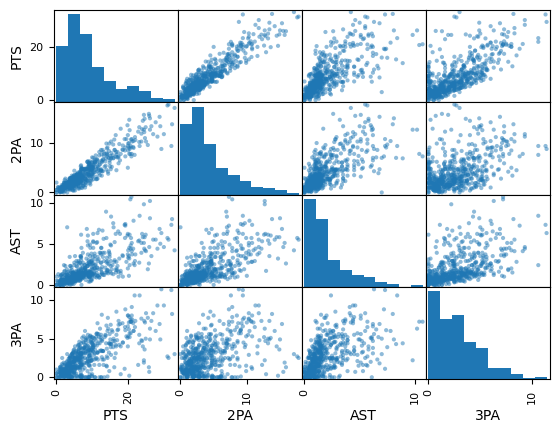

In [28]:
from pandas.plotting import scatter_matrix
attr = ['PTS', '2PA', 'AST', '3PA']
scatter_matrix(nba[attr])

In [29]:
from sklearn.model_selection import train_test_split
nba_train, nba_test = train_test_split(nba, test_size = 0.33, random_state = 42)

In [30]:
# dropping labels for training set
nba = nba_train.drop('PTS', axis = 1)
nba_labels = nba_train['PTS'].copy()

In [31]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [32]:
# replacing NaN values with 0 and scaling values
nbanum_pipeline = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value=0)),
                         ('scaler', StandardScaler())])

In [33]:
nbanum = nba.drop('Position', axis = 1)
num_attr = list(nbanum)
cat_attr = ['Position']
ct = ColumnTransformer([('num', nbanum_pipeline, num_attr),
                       ('cat', OneHotEncoder(), cat_attr)])
nba_ready = ct.fit_transform(nba)

In [34]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(nba_ready, nba_labels)

LinearRegression()

In [35]:
from sklearn.metrics import mean_squared_error
nba_pred = lin_reg.predict(nba_ready)
lin_rmse = np.sqrt(mean_squared_error(nba_labels, nba_pred))
lin_rmse

1.1592378984835898

In [36]:
from sklearn.metrics import mean_absolute_error
lin_mae = mean_absolute_error(nba_labels, nba_pred)
lin_mae

0.8231012775916193

In [37]:
first5 = nba.iloc[:5]
first5_labels = nba_labels.iloc[:5]
first5_t = ct.transform(first5)
print('Predictions:', lin_reg.predict(first5_t))

Predictions: [ 3.87928331 29.97093502  5.84633987 24.26009177 19.82997732]


In [38]:
print('Labels:', list(first5_labels))

Labels: [3.8, 28.9, 6.2, 24.5, 21.6]


In [39]:
from sklearn.model_selection import cross_val_score
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())
scores = cross_val_score(lin_reg, nba_ready, nba_labels, scoring = 'neg_mean_squared_error', cv=10)
rmse_scores = np.sqrt(-scores)
display_scores(rmse_scores)

Scores: [1.21305817 1.50750102 0.97206793 1.00421118 1.5201377  1.25498348
 1.25060072 1.3587511  1.25403577 0.79134429]
Mean: 1.2126691366438025
Standard deviation: 0.22059049123372645


In [40]:
from sklearn.svm import SVR
svr_lin = SVR(kernel='linear')
svr_lin.fit(nba_ready, nba_labels)
nba_pred = svr_lin.predict(nba_ready)
svr_rmse = np.sqrt(mean_squared_error(nba_labels, nba_pred))
svr_rmse

1.1806327353299089

In [41]:
svr_scores = cross_val_score(svr_lin, nba_ready, nba_labels, scoring = 'neg_mean_squared_error', cv=10)
svr_rmse_scores = np.sqrt(-svr_scores)
display_scores(svr_rmse_scores)

Scores: [1.27954089 1.47231223 0.93435265 0.9798895  1.58200837 1.29888702
 1.12228628 1.30594593 1.23814039 0.75863208]
Mean: 1.197199532197836
Standard deviation: 0.23846441167458418


In [42]:
from sklearn.ensemble import RandomForestRegressor
freg = RandomForestRegressor(random_state=42)
freg.fit(nba_ready, nba_labels)

RandomForestRegressor(random_state=42)

In [43]:
nba_pred = freg.predict(nba_ready)
freg_rmse = np.sqrt(mean_squared_error(nba_labels, nba_pred))
freg_rmse

0.5566638755659552

In [44]:
freg_scores = cross_val_score(freg, nba_ready, nba_labels, scoring='neg_mean_squared_error', cv=10)
freg_rmse_scores = np.sqrt(-freg_scores)
display_scores(freg_rmse_scores)

Scores: [1.81317184 1.87121459 1.18383675 1.25676226 2.05768123 1.51911516
 1.42558852 1.87247555 1.31786424 0.96587977]
Mean: 1.5283589911413598
Standard deviation: 0.34074404607138825


In [45]:
from sklearn.model_selection import GridSearchCV

param_grid = [{'n_estimators':[60, 70, 80], 'max_features':[4, 6, 8, 12]},
             {'bootstrap':[False], 'n_estimators':[5, 10, 15], 'max_features':[2, 3, 4]}]
new_freg = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(new_freg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(nba_ready, nba_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [4, 6, 8, 12],
                          'n_estimators': [60, 70, 80]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [5, 10, 15]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [46]:
grid_search.best_params_

{'max_features': 12, 'n_estimators': 70}

In [47]:
best_freg = grid_search.best_estimator_

In [48]:
fi = best_freg.feature_importances_
fi

array([8.84512940e-03, 1.10392548e-01, 8.58827305e-01, 7.74894162e-03,
       3.46513684e-03, 3.63790402e-03, 5.00839797e-03, 2.36365287e-04,
       5.14576842e-04, 3.31748861e-04, 4.52028995e-04, 5.39917362e-04])

In [49]:
cat_encoder = ct.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attr + cat_one_hot_attribs
sorted(zip(fi, attributes), reverse=True)

[(0.8588273046208063, '2PA'),
 (0.11039254817994212, '3PA'),
 (0.008845129398187917, 'GP'),
 (0.007748941622804866, 'DRB'),
 (0.005008397965329884, 'PF'),
 (0.003637904023380762, 'STL'),
 (0.003465136842945348, 'AST'),
 (0.0005399173622328965, 'SG'),
 (0.0005145768418240525, 'PF'),
 (0.00045202899475220567, 'SF'),
 (0.0003317488612656274, 'PG'),
 (0.0002363652865281636, 'C')]

In [50]:
best_freg_scores = cross_val_score(best_freg, nba_ready, nba_labels, scoring='neg_mean_squared_error', cv=10)
bfreg_rmse_scores = np.sqrt(-best_freg_scores)
display_scores(bfreg_rmse_scores)

Scores: [1.85745654 1.84878458 1.16584852 1.25673185 2.02967686 1.49150662
 1.384898   1.85310538 1.33602596 0.96680154]
Mean: 1.519083584503869
Standard deviation: 0.33858090719573436


In [51]:
from sklearn.tree import DecisionTreeRegressor
dtreg = DecisionTreeRegressor(random_state=42)
dtreg.fit(nba_ready, nba_labels)

DecisionTreeRegressor(random_state=42)

In [52]:
nba_pred = dtreg.predict(nba_ready)
dt_rmse = np.sqrt(mean_squared_error(nba_labels, nba_pred))
dt_rmse

0.0

In [53]:
dt_rmse_scores = np.sqrt(-cross_val_score(dtreg, nba_ready, nba_labels, scoring='neg_mean_squared_error', cv=10))
display_scores(dt_rmse_scores)

Scores: [2.63490089 3.02553944 1.57691682 1.60060752 2.34911331 1.94479362
 2.37358145 1.5817536  1.83492355 1.67837554]
Mean: 2.060050573776776
Standard deviation: 0.4824310121976252


In [54]:
nba_ftest = nba_test.drop('PTS', axis=1)
nba_tlabels = nba_test['PTS'].copy()
nba_test_prep = ct.transform(nba_test)
final_predictions_freg = best_freg.predict(nba_test_prep)
final_rmse_freg = np.sqrt(mean_squared_error(nba_tlabels, final_predictions_freg))
final_rmse_freg

1.3823126987612522

In [55]:
final_predictions_lin = lin_reg.predict(nba_test_prep)
final_rmse_lin = np.sqrt(mean_squared_error(nba_tlabels, final_predictions_lin))
final_rmse_lin

1.078292018801693

In [56]:
final_predictions_svr = svr_lin.predict(nba_test_prep)
final_rmse_svr = np.sqrt(mean_squared_error(nba_tlabels, final_predictions_svr))
final_rmse_svr

1.0975470312025764

In [57]:
final_predictions_tree = dtreg.predict(nba_test_prep)
final_rmse = np.sqrt(mean_squared_error(nba_tlabels, final_predictions_tree))
final_rmse

2.0104502262825488

Based on the cross validation and test set scores, the two best models are the Linear Regression and SVR models. I lean towards the Linear Regression model becuase of the lower standared deviation of cross validation scores and the lower RMSE score on the test set.